# 포트폴리오 분석 — KR/US 자동매매 시스템 실측 리포트

이 노트북은 이 저장소(`quant_trading_kiwoom`)가 실제로 남긴 체결 원장·자본 스냅샷을
그대로 불러와 수치·그래프로 보여준다. 숫자를 지어내지 않는다 — 파일이 없으면
"데이터 없음"이라고 정직하게 출력한다.

작성일: 실행 시점 기준 (아래 셀에서 자동 표기)

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from datetime import datetime, timezone

print(f"실행 시각(UTC): {datetime.now(timezone.utc).isoformat(timespec='seconds')}")

# --- 저장소 루트 탐색(노트북은 backtest/ 에 있지만, 실행 cwd 는 nbconvert 설정에 따라 달라질 수 있어 방어적으로 찾는다) ---
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    return start

REPO_ROOT = find_repo_root(Path.cwd())
print(f"저장소 루트: {REPO_ROOT}")

# --- 한글 폰트 탐지 (macOS: AppleGothic 계열, 없으면 영문 라벨로 폴백) ---
_KOREAN_FONT_CANDIDATES = [
    "AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic",
    "Noto Sans CJK KR", "Noto Sans KR",
]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
KO_FONT = next((f for f in _KOREAN_FONT_CANDIDATES if f in _available_fonts), None)
if KO_FONT:
    plt.rcParams["font.family"] = KO_FONT
    plt.rcParams["axes.unicode_minus"] = False
    print(f"한글 폰트 사용: {KO_FONT}")
else:
    print("한글 폰트를 찾지 못함 — 그래프 라벨은 영문으로 폴백한다")


def kr(korean: str, english: str) -> str:
    '''한글 폰트가 있으면 한글, 없으면 영문 라벨.'''
    return korean if KO_FONT else english


def check_file(path: Path, hint: str) -> bool:
    if not path.exists():
        print(f"[데이터 없음] {path} — {hint}")
        return False
    return True


pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.dpi"] = 100

실행 시각(UTC): 2026-08-29T08:54:28+00:00
저장소 루트: /Users/eric/Documents/GitHub/Quant_Trading
한글 폰트 사용: AppleGothic


## 1. 개요

**무엇인가**: KR(한국)·US(미국) 정규장에서 11개 전략을 병렬로 운용하는 개인
자동매매 엔진 (paper 단계, 실계좌 아님). 관심종목은 텔레그램 `/watch` 명령과
자체 시황 리포트의 확신도 엔진(`watch-score`)이 채운다 — 이 경로에는 LLM이
없다. 시세는 키움 웹소켓 우선, Toss REST 폴백. 주문 집행은 Toss 단일.

**데이터**: 아래 셀에서 체결 원장(`data/state/trades.jsonl`)과 자본 스냅샷
(`data/ledger/equity_curve.jsonl`)을 로컬 동기화본에서 직접 읽는다 — 숫자는
전부 실측이고, 표본 크기는 매우 작다(자본 스냅샷 11행, 아래에서 명시).

In [2]:
TRADES_PATH = REPO_ROOT / "data" / "state" / "trades.jsonl"
EQUITY_PATH = REPO_ROOT / "data" / "ledger" / "equity_curve.jsonl"

trades_df = pd.DataFrame()
if check_file(
    TRADES_PATH,
    "EC2에서 동기화 필요: scp $QT_SSH_HOST:~/quant_trading_kiwoom/data/state/trades.jsonl data/state/",
):
    trades_df = pd.read_json(TRADES_PATH, lines=True)
    trades_df["ts"] = pd.to_datetime(trades_df["ts"], utc=True)

equity_df = pd.DataFrame()
if check_file(
    EQUITY_PATH,
    "EC2에서 동기화 필요: scp $QT_SSH_HOST:~/quant_trading_kiwoom/data/ledger/equity_curve.jsonl data/ledger/",
):
    equity_df = pd.read_json(EQUITY_PATH, lines=True)
    equity_df["recorded_at"] = pd.to_datetime(equity_df["recorded_at"], utc=True)

if not trades_df.empty:
    print(
        f"체결 원장: {len(trades_df)}행 · 기간 {trades_df['ts'].min().date()} ~ "
        f"{trades_df['ts'].max().date()} (UTC) · 전략 {trades_df['strategy_id'].nunique()}개 "
        f"· 시장 {sorted(trades_df['market'].unique())}"
    )
if not equity_df.empty:
    print(
        f"자본 스냅샷: {len(equity_df)}행 · {equity_df['date'].min()} ~ {equity_df['date'].max()} "
        "— 표본이 매우 작다(§5 참고)"
    )

체결 원장: 461행 · 기간 2026-08-10 ~ 2026-08-28 (UTC) · 전략 10개 · 시장 ['KR', 'US']
자본 스냅샷: 11행 · 2026-08-24 00:00:00 ~ 2026-08-28 00:00:00 — 표본이 매우 작다(§5 참고)


## 2. 아키텍처 요약

코드는 기능이 아니라 **"틀렸을 때 무엇을 잃는가"**로 4개 평면으로 나뉜다:

| 평면 | 디렉토리 | 틀리면 | 허용 |
|---|---|---|---|
| 수집 | `quant/collect/` | 데이터가 빈다 | 스크래핑, LLM, 실패, 재시도 |
| 분석 | `quant/analyze/` | 선정이 나빠진다 | LLM, 느린 배치 |
| **거래** | `quant/trade/` | **돈을 잃는다** | 결정론적 코드만 |
| 제어 | `quant/control/` | 다음 세션이 나빠진다 | 자동 조정, 실험, 롤백 |

그 아래 `quant/core/`(순수 도메인, 외부 의존 0), `quant/adapters/`(네트워크·디스크
I/O는 오직 여기서만), `quant/apps/`(진입점)가 받친다. 가장 중요한 규칙은
"`quant/collect/`·`quant/analyze/`는 `quant/trade/`를 임포트하지 않는다" —
스크래핑한 뉴스가 주문으로 이어지는 경로를 코드 수준에서 끊는 것이다. 뉴스는
*유니버스만* 편집하고, 진입은 전략이 가격으로 판단한다.

findfont: Failed to find font weight bold, now using 400.


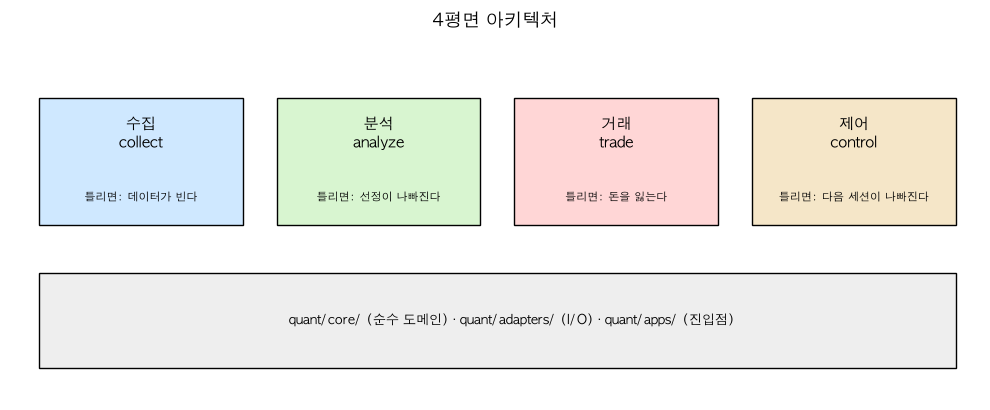

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4.6)
ax.axis("off")

planes = [
    (kr("수집\ncollect", "collect"), "데이터가 빈다", "#cfe8ff"),
    (kr("분석\nanalyze", "analyze"), "선정이 나빠진다", "#d8f5d0"),
    (kr("거래\ntrade", "trade"), kr("돈을 잃는다", "loses money"), "#ffd6d6"),
    (kr("제어\ncontrol", "control"), "다음 세션이 나빠진다", "#f5e6c8"),
]
box_w, gap = 2.1, 0.35
x = 0.3
for name, risk, color in planes:
    ax.add_patch(plt.Rectangle((x, 2.2), box_w, 1.6, facecolor=color, edgecolor="black"))
    ax.text(x + box_w / 2, 3.35, name, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(x + box_w / 2, 2.55, kr(f"틀리면: {risk}", f"if wrong: {risk}"), ha="center", va="center", fontsize=8)
    x += box_w + gap

ax.add_patch(plt.Rectangle((0.3, 0.4), x - gap - 0.3, 1.2, facecolor="#eeeeee", edgecolor="black"))
ax.text(
    (x - gap) / 2 + 0.3,
    1.0,
    kr("quant/core/ (순수 도메인) · quant/adapters/ (I/O) · quant/apps/ (진입점)",
       "quant/core/ (domain) · quant/adapters/ (I/O) · quant/apps/ (entrypoints)"),
    ha="center", va="center", fontsize=9,
)
ax.set_title(kr("4평면 아키텍처", "4-plane architecture"), fontsize=13)
plt.tight_layout()
plt.show()

## 3. 전략별 성적표

`trades.jsonl`에서 **매도(sell) 체결을 왕복(round-trip) 1건으로** 집계한다.
KR은 원화, US는 달러로 손익 단위가 다르므로 **금액(총손익)은 (전략, 시장)별로
분리**하고, bp(명목 대비 손익 = `realized_pnl / (qty × price) × 10000`)는
통화와 무관한 단위라 전략 간 비교에 쓴다. 여기서 `realized_pnl`은 **수수료
차감 전(gross)** 값이다 — 수수료는 §4에서 별도로 다룬다.

In [4]:
if not trades_df.empty:
    sells = trades_df[trades_df["side"] == "sell"].copy()
    sells["notional"] = sells["qty"] * sells["price"]
    sells["bp"] = sells["realized_pnl"] / sells["notional"] * 10000
    sells["win"] = sells["realized_pnl"] > 0

    scoreboard = (
        sells.groupby(["strategy_id", "market"])
        .agg(
            건수=("realized_pnl", "size"),
            승률_pct=("win", "mean"),
            총손익_gross=("realized_pnl", "sum"),
            평균bp_gross=("bp", "mean"),
        )
        .reset_index()
    )
    scoreboard["승률_pct"] = (scoreboard["승률_pct"] * 100).round(1)
    scoreboard["평균bp_gross"] = scoreboard["평균bp_gross"].round(1)
    scoreboard["총손익_gross"] = scoreboard["총손익_gross"].round(0)
    scoreboard = scoreboard.sort_values("평균bp_gross")
    display(scoreboard)
else:
    print("[데이터 없음] trades_df 가 비어 있어 성적표를 만들 수 없다")

,strategy_id,market,건수,승률_pct,총손익_gross,평균bp_gross
7,news_scalp,KR,6,16.70,"-318,189.00",-157.60
8,orb_scan,KR,8,25.00,"-92,823.00",-86.20
6,news_momentum,KR,6,16.70,"-20,394.00",-77.20
4,intraday_scan,KR,24,29.20,"-272,716.00",-76.80
3,frgn_accumulate,KR,1,0.00,"-1,878.00",-73.50
10,scalp_1m,KR,70,31.40,"-1,153,590.00",-30.40
9,pullback_impulse,US,8,37.50,15.00,-25.40
0,confluence,KR,28,42.90,"-328,446.00",-4.60
5,intraday_scan,US,18,44.40,4.00,-1.60
11,scalp_1m,US,37,32.40,-14.00,7.80


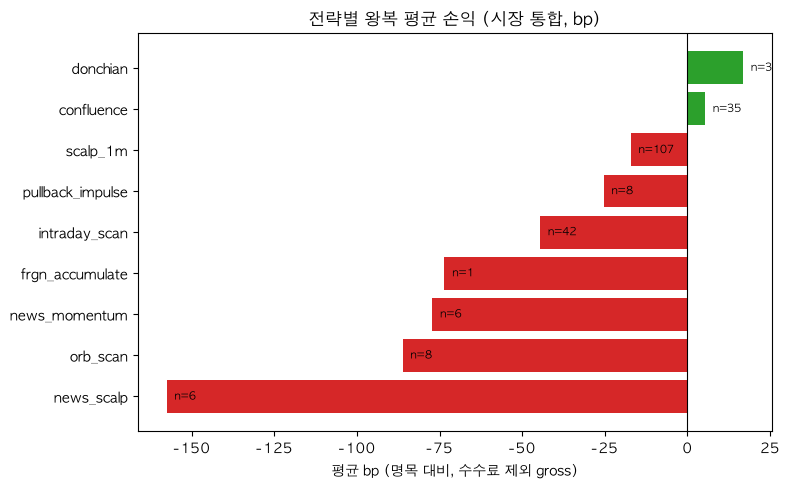

In [5]:
if not trades_df.empty and not sells.empty:
    agg_bp = (
        sells.groupby("strategy_id")
        .agg(건수=("bp", "size"), 평균bp=("bp", "mean"))
        .sort_values("평균bp")
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in agg_bp["평균bp"]]
    ax.barh(agg_bp.index, agg_bp["평균bp"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    for i, (n, v) in enumerate(zip(agg_bp["건수"], agg_bp["평균bp"])):
        ax.text(v, i, f"  n={n}", va="center", fontsize=8)
    ax.set_xlabel(kr("평균 bp (명목 대비, 수수료 제외 gross)", "avg bp (notional, gross ex-fee)"))
    ax.set_title(kr("전략별 왕복 평균 손익 (시장 통합, bp)", "Avg round-trip P&L by strategy (bp, all markets)"))
    plt.tight_layout()
    plt.show()

## 4. 비용의 산수

`realized_pnl`은 gross(수수료 차감 전)다. 실제 순손익을 보려면 매수·매도 양쪽
체결에 붙은 `fee`를 따로 빼야 한다. 시장별로 통화가 다르므로(KR=원, US=달러)
합계도 시장별로 분리한다.

**착수보고서 실측 기준선**(라이브 원장 2026-08-10~21, 종결 103건, 전략 7종):
수수료 793,309원을 빼기 전에도 **-1,332,799원 — 전략 7종 전부 음수**였다
(`docs/vault/변경기록.md`). 아래는 이 노트북이 다루는 확장된 표본(2026-08-10~28,
461행, 전략 10종)으로 같은 계산을 다시 한 것이다 — 숫자가 다를 수 있다.

In [6]:
if not trades_df.empty:
    cost_rows = []
    for mkt in sorted(trades_df["market"].unique()):
        sub_all = trades_df[trades_df["market"] == mkt]
        sub_sell = sells[sells["market"] == mkt]
        fee_sum = sub_all["fee"].sum()
        gross_pnl = sub_sell["realized_pnl"].sum()
        net_pnl = gross_pnl - fee_sum
        cost_rows.append(
            {
                "시장": mkt,
                "통화": "KRW" if mkt == "KR" else "USD",
                "체결건수": len(sub_all),
                "수수료합계": round(fee_sum, 0),
                "실현손익_수수료전(gross)": round(gross_pnl, 0),
                "순손익_수수료후": round(net_pnl, 0),
            }
        )
    cost_df = pd.DataFrame(cost_rows)
    display(cost_df)

    for _, row in cost_df.iterrows():
        gross_sign = "양수" if row["실현손익_수수료전(gross)"] > 0 else "음수"
        print(
            f"{row['시장']}: 수수료 전에도 {gross_sign} "
            f"({row['실현손익_수수료전(gross)']:,.0f} {row['통화']}), "
            f"수수료 {row['수수료합계']:,.0f} {row['통화']} 차감 후 "
            f"{row['순손익_수수료후']:,.0f} {row['통화']}"
        )
else:
    print("[데이터 없음]")

,시장,통화,체결건수,수수료합계,실현손익_수수료전(gross),순손익_수수료후
0,KR,KRW,310,"928,521.00","-2,188,036.00","-3,116,557.00"
1,US,USD,151,255.00,42.00,-212.00


KR: 수수료 전에도 음수 (-2,188,036 KRW), 수수료 928,521 KRW 차감 후 -3,116,557 KRW
US: 수수료 전에도 양수 (42 USD), 수수료 255 USD 차감 후 -212 USD


In [7]:
cost_assumptions = pd.DataFrame(
    {
        "구분": [kr("US 개별주/ETF", "US stock/ETF"), kr("KR 개별주", "KR individual stock"), "KR ETF"],
        "왕복비용_bp_가정": [26, 30, 4],
    }
).set_index("구분")
print(kr(
    "왕복 비용 가정(config/settings.yaml 주석 기준 — 실측이 아니라 설계 가정):",
    "Round-trip cost assumption (from config/settings.yaml comments — assumption, not measured):",
))
display(cost_assumptions)
print(kr(
    "KR ETF만 왕복 비용이 엣지보다 낮을 여지가 있는 유일한 venue라는 게 이 저장소의 반복 결론이다.",
    "KR ETF is the only venue where round-trip cost plausibly stays below the edge — a recurring conclusion in this repo.",
))

왕복 비용 가정(config/settings.yaml 주석 기준 — 실측이 아니라 설계 가정):


,왕복비용_bp_가정
구분,
US 개별주/ETF,26
KR 개별주,30
KR ETF,4


KR ETF만 왕복 비용이 엣지보다 낮을 여지가 있는 유일한 venue라는 게 이 저장소의 반복 결론이다.


## 5. 자본 곡선과 알파

`equity_curve.jsonl`은 (날짜, 시장)별 스냅샷이다 — **표본 11행**, 2026-08-24
~08-28 5거래일치. `total_krw`는 시장과 무관하게 원화로 기록돼 있어 곧바로
비교할 수 있다. 벤치마크(`benchmark_symbol`/`benchmark_close`)는 가장 최근
행(2026-08-28, QQQ)에만 붙기 시작했다 — **표본 1건**이라 곡선이 아니라 점으로만
보고한다.

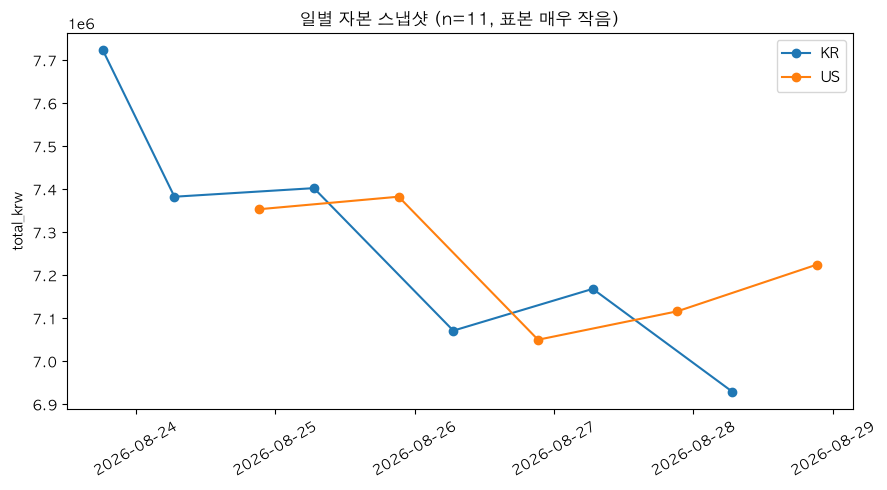

In [8]:
if not equity_df.empty:
    equity_df = equity_df.sort_values("recorded_at")
    fig, ax = plt.subplots(figsize=(9, 5))
    for mkt, grp in equity_df.groupby("market"):
        ax.plot(grp["recorded_at"], grp["total_krw"], marker="o", label=mkt)
    ax.set_title(kr(
        f"일별 자본 스냅샷 (n={len(equity_df)}, 표본 매우 작음)",
        f"Daily equity snapshots (n={len(equity_df)}, tiny sample)",
    ))
    ax.set_ylabel("total_krw")
    ax.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("[데이터 없음] equity_df 가 비어 있다")

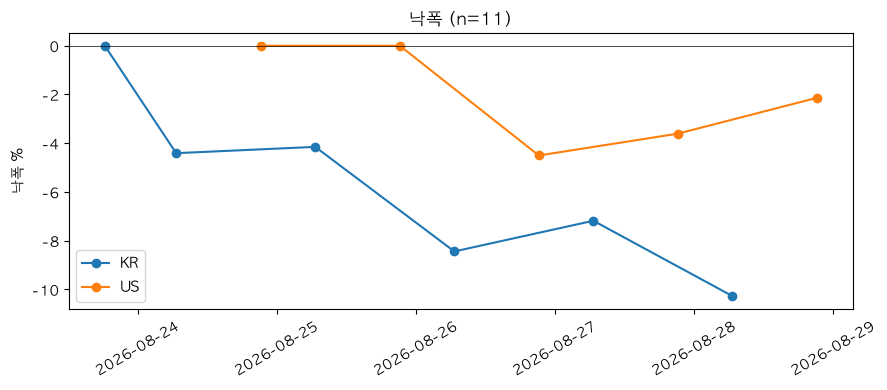

벤치마크 병기 시작: QQQ 종가 716.72 (2026-08-28 00:00:00) — 표본 1건, 곡선을 그릴 수 없다
[데이터 없음] /Users/eric/Documents/GitHub/Quant_Trading/data/history — 벤치마크(QQQ/SPY/069500/229200) 장기 시계열 없음 — EC2에서 동기화 필요: scp -r $QT_SSH_HOST:~/quant_trading_kiwoom/data/history data/


In [9]:
if not equity_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    for mkt, grp in equity_df.groupby("market"):
        grp = grp.sort_values("recorded_at")
        running_max = grp["total_krw"].cummax()
        dd = (grp["total_krw"] - running_max) / running_max * 100
        ax.plot(grp["recorded_at"], dd, marker="o", label=mkt)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel(kr("낙폭 %", "drawdown %"))
    ax.set_title(kr(f"낙폭 (n={len(equity_df)})", f"Drawdown (n={len(equity_df)})"))
    ax.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    if "benchmark_symbol" in equity_df.columns:
        bench = equity_df.dropna(subset=["benchmark_symbol"])
        if not bench.empty:
            last = bench.iloc[-1]
            print(
                f"벤치마크 병기 시작: {last['benchmark_symbol']} 종가 {last['benchmark_close']} "
                f"({last['date']}) — 표본 1건, 곡선을 그릴 수 없다"
            )
        else:
            print("벤치마크 필드가 아직 채워진 행이 없다")

    hist_dir = REPO_ROOT / "data" / "history"
    if not check_file(
        hist_dir,
        "벤치마크(QQQ/SPY/069500/229200) 장기 시계열 없음 — EC2에서 동기화 필요: "
        "scp -r $QT_SSH_HOST:~/quant_trading_kiwoom/data/history data/",
    ):
        pass
    else:
        for sym in ["QQQ", "SPY", "069500", "229200"]:
            sym_dir = hist_dir / sym / "1d"
            if sym_dir.exists() and list(sym_dir.glob("*.parquet")):
                print(f"{sym}: 1d parquet 발견 — 벤치마크 곡선에 사용 가능")
            else:
                print(f"[데이터 없음] {sym} 1d parquet — 건너뜀")

## 6. 통계적 규율 — "최고 성적"이 우연일 확률

`quant/backtest/statistics.py`의 `expected_max_sharpe`(Bailey, Borwein, López
de Prado & Zhu, 2014)는 **엣지가 정확히 0인 전략을 N번 시험하면, 그중 최고
샤프는 순전히 우연으로 얼마나 높게 나오는가**를 계산한다. 이 저장소는 파라미터·
전략 변형을 반복 시험하는 루프를 돌리므로, 성과를 "엣지가 있다"고 읽기 전에
이 부풀림을 반드시 감안해야 한다.

**다중검정 신고**: 아래 데모는 시행 횟수 `n_trials=8`을 기준선으로 표시한다.
이 저장소의 변경기록(`docs/vault/변경기록.md`)에는 개별 튜닝 결정마다 각기
다른 시행 횟수가 명시돼 있다(예: "탐색 6회 고지", "탐색 20회", "탐색 4회") —
전체 이력을 통틀어 정직하게 세면 8보다 많을 개연성이 높다. `statistics.py`
자신의 경고대로 "축소해 세면 이 함수는 그만큼 관대해진다"는 점을 감안해,
아래 곡선은 1~100회 전 구간을 함께 보여준다.

In [10]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from quant.backtest.statistics import expected_max_sharpe

n_obs = len(sells) if not trades_df.empty and not sells.empty else 216
print(f"n_obs(관측 수, 종결된 왕복 표본으로 근사): {n_obs}")

trial_grid = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 75, 100]
demo = pd.DataFrame(
    {
        "n_trials": trial_grid,
        "E_max_SR_per_obs": [expected_max_sharpe(n, n_obs) for n in trial_grid],
    }
)
demo["E_max_SR_annualized"] = demo["E_max_SR_per_obs"] * (252 ** 0.5)
display(demo.round(4))

n_obs(관측 수, 종결된 왕복 표본으로 근사): 216


,n_trials,E_max_SR_per_obs,E_max_SR_annualized
0,1,0.00,0.00
1,2,0.04,0.56
2,3,0.06,0.92
3,5,0.08,1.29
4,8,0.10,1.58
5,10,0.11,1.70
6,15,0.12,1.91
7,20,0.13,2.05
8,30,0.14,2.24
9,50,0.15,2.46


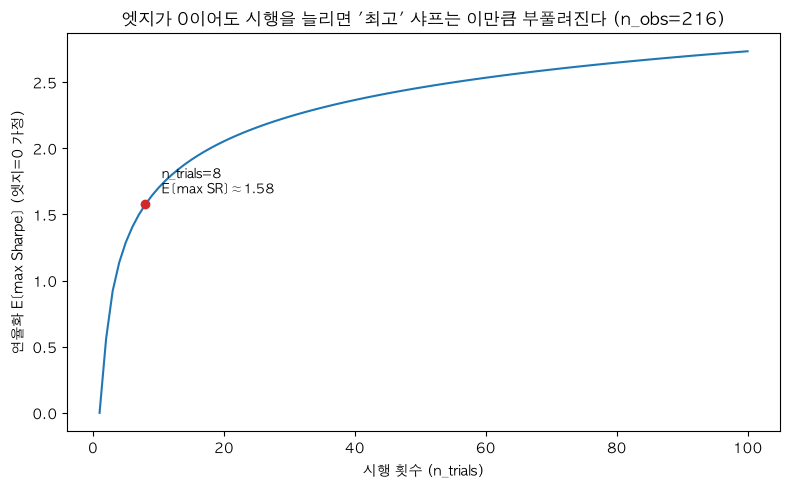

해석: n_obs=216에서 무가치한 전략을 8개 시험하면, 그중 최고는 순전히 우연으로 연율 샤프 약 1.58쯤으로 보인다. 우리가 보고하는 실제 샤프가 이 선을 크게 웃돌지 못한다면, 그건 엣지가 아니라 탐색의 기록이다.


In [11]:
xs = np.arange(1, 101)
ys = [expected_max_sharpe(n, n_obs) * (252 ** 0.5) for n in xs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ys, color="#1f77b4")

highlight_n = 8
highlight_y = expected_max_sharpe(highlight_n, n_obs) * (252 ** 0.5)
ax.scatter([highlight_n], [highlight_y], color="#d62728", zorder=5)
ax.annotate(
    f"n_trials={highlight_n}\nE[max SR]≈{highlight_y:.2f}",
    (highlight_n, highlight_y),
    textcoords="offset points",
    xytext=(12, 8),
    fontsize=9,
)
ax.set_xlabel(kr("시행 횟수 (n_trials)", "number of trials"))
ax.set_ylabel(kr("연율화 E[max Sharpe] (엣지=0 가정)", "annualized E[max Sharpe] (edge=0)"))
ax.set_title(kr(
    f"엣지가 0이어도 시행을 늘리면 '최고' 샤프는 이만큼 부풀려진다 (n_obs={n_obs})",
    f"Even with zero edge, more trials inflate the 'best' Sharpe (n_obs={n_obs})",
))
plt.tight_layout()
plt.show()

print(
    f"해석: n_obs={n_obs}에서 무가치한 전략을 {highlight_n}개 시험하면, "
    f"그중 최고는 순전히 우연으로 연율 샤프 약 {highlight_y:.2f}쯤으로 보인다. "
    "우리가 보고하는 실제 샤프가 이 선을 크게 웃돌지 못한다면, 그건 엣지가 아니라 탐색의 기록이다."
)

## 7. 정직한 결론

- **단계**: 이 저장소는 여전히 **paper 트레이딩**이다. 위 숫자 중 어떤 것도
  실계좌 손익이 아니다.
- **표본 한계**: 체결 원장은 461행(약 3주)이고, 자본 스냅샷은 **11행(5거래일)**
  뿐이다. §5의 낙폭·자본 곡선은 통계적으로 아무것도 증명하지 못한다 — 방향만
  보여줄 뿐이다. 전략별 왕복 표본도 5~205건으로 전략마다 크게 다르다(§3).
- **대회 진행 중**: 이 저장소는 전략 11종을 동일 조건에서 병렬로 굴리는
  "대회" 체제다. 우승 전략이 아니라 각 전략의 실측 승률·payoff가 자본
  배분(`run scoreboard`)을 결정한다 — 이 노트북의 §3·§4가 그 원재료다.
- **실계좌 전환 조건**(`docs/vault/착수보고서.md` "완성"의 정의): 5개 조건 중
  지금은 1번(자동 루프가 매일 돈다)만 참이다. 종결 거래 30건 이상으로
  "어떤 근거가 돈이 됐는지" 답할 수 있어야 하고, 최소 한 전략이
  `burn_in → verified`로 승격돼야 한다. 아직이다.
- **왜 정직성이 설득력인가**: §6에서 보였듯, 반복 시험은 엣지 없이도 좋은
  숫자를 만든다. 이 노트북이 신뢰를 얻는 방법은 좋은 숫자를 고르는 게 아니라,
  나쁜 숫자(§4의 수수료 전 음수, §3의 음수 bp 전략들)를 숨기지 않는 것이다.